In [1]:
%load_ext Cython

In [2]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
matplotlib.use('module://matplotlib_inline.backend_inline')
import yaml
import time
import pickle as pkl
import os
import sys
import numpy as np
from matplotlib import cm
from scipy import signal
from scipy.signal import butter, welch, filtfilt, periodogram, savgol_filter
import pandas as pd
import glob
from scipy.optimize import curve_fit
from scipy.optimize import fminbound
import scipy.linalg as linalg
import scipy as sp
# sys.path.append("/home/cryo/.local/lib/python3.10/site-packages/")
# import nbimporter

#will need to edit this
sys.path.append('../../Utilities')
# from SignalCore import *

plt.ion()
%matplotlib inline

SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE, family='serif')          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE, labelsize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE, facecolor='white') 

In [3]:
# Import useful wrapper functions

sys.path.append("/home/cryo/docker/pysmurf/dev/v8.0.0-rc3_rfsoc/pysmurf/scratch/adroster")
from utils import *
from parity_timestream import *

## Initialize pysmurf control instance

In [ ]:
import pysmurf.client
import epics
import os
import time

%matplotlib inline

epics_prefix="smurf_server_s3"
config_file=os.path.abspath("/usr/local/src/pysmurf/cfg_files/lab1/experiment_lab1_rfsoc.cfg")
S = pysmurf.client.SmurfControl(epics_root=epics_prefix,cfg_file=config_file,setup=False,make_logfile=False,shelf_manager="shm-smrf-sp01")

## Dump versions of everything
# Python version
print(sys.version)
import pysmurf
pysmurf.__version__
cwd=os.getcwd()
os.chdir('/usr/local/src/pysmurf/')
#print(str(!git branch))
#print(!git rev-parse --short HEAD)
print(S.get_fpga_git_hash_short())
print(S.config.filename)

## Set LOs

In [102]:
LO_freq_MHz_band0 = 6940 + 750
LO_freq_MHz_band1 = 6440 + 750

## Band center settings

In [47]:
band0 = 0
band1 = 1
band2 = 2

In [5]:
S.all_off()

[ 2026-05-28 21:39:14 ]  Turning off tones
[ 2026-05-28 21:39:29 ]  Turning off flux ramp
[ 2026-05-28 21:39:29 ]  Turning off all TES biases


In [103]:
S.set_band_center_mhz(band0,LO_freq_MHz_band0-750)
S.set_band_center_mhz(band1,LO_freq_MHz_band1-750)

In [104]:
S.get_band_center_mhz(band=band0)

6940.0

In [105]:
S.get_band_center_mhz(band=band1)

6440.0

In [138]:
f_QPD2 = 6437.5
f_QPD4 = 6936.75

## Freq sweep

[ 2026-05-28 22:50:36 ]  Sweeping across frequencies 6920.0MHz to 6960.0MHz. Averaging 10 traces.
[ 2026-05-28 22:50:36 ]  Working on band 0
[ 2026-05-28 22:50:41 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-28 22:50:41 ]  Working on band 0
[ 2026-05-28 22:50:46 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-28 22:50:46 ]  Working on band 0
[ 2026-05-28 22:50:52 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-28 22:50:52 ]  Working on band 0
[ 2026-05-28 22:50:57 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-28 22:50:58 ]  Working on band 0
[ 2026-05-28 22:51:03 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-28 22:51:03 ]  Working on band 0
[ 2026-05-28 22:51:09 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-28 22:51:09 ]  Working on band 0
[ 2026-05-28 22:51:15 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-28 22:51:16 ]  Working on band 0
[ 2026-05-28 22:51:21 ]  serial f

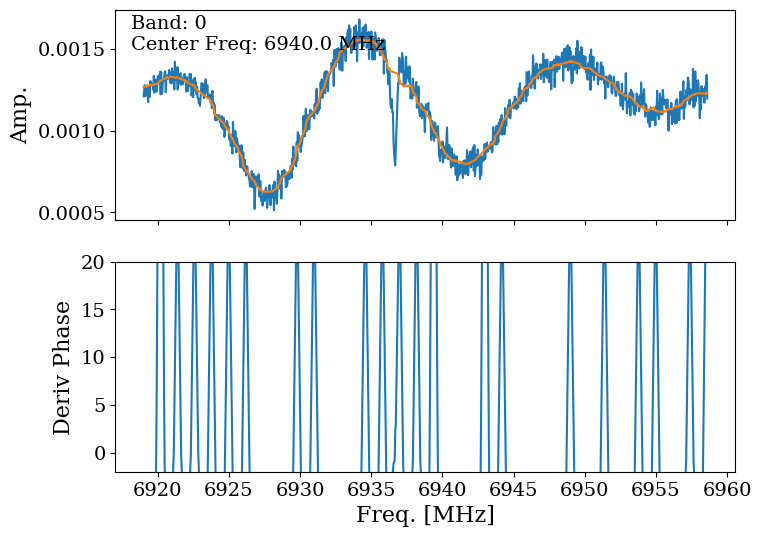

In [58]:
f0, resp0 = freqSweep(S, band=0, start_freq=-20, stop_freq=20, subband=None, tone_power=12, n_avg = 10
                      , makeplot=True)

[ 2026-05-29 00:46:48 ]  Sweeping across frequencies 6920.0MHz to 6960.0MHz. Averaging 10 traces.
[ 2026-05-29 00:46:48 ]  Working on band 0
[ 2026-05-29 00:46:54 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:46:54 ]  Working on band 0
[ 2026-05-29 00:47:00 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:47:00 ]  Working on band 0
[ 2026-05-29 00:47:06 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:47:06 ]  Working on band 0
[ 2026-05-29 00:47:11 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:47:11 ]  Working on band 0
[ 2026-05-29 00:47:17 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:47:18 ]  Working on band 0
[ 2026-05-29 00:47:23 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:47:23 ]  Working on band 0
[ 2026-05-29 00:47:29 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:47:29 ]  Working on band 0
[ 2026-05-29 00:47:35 ]  serial f

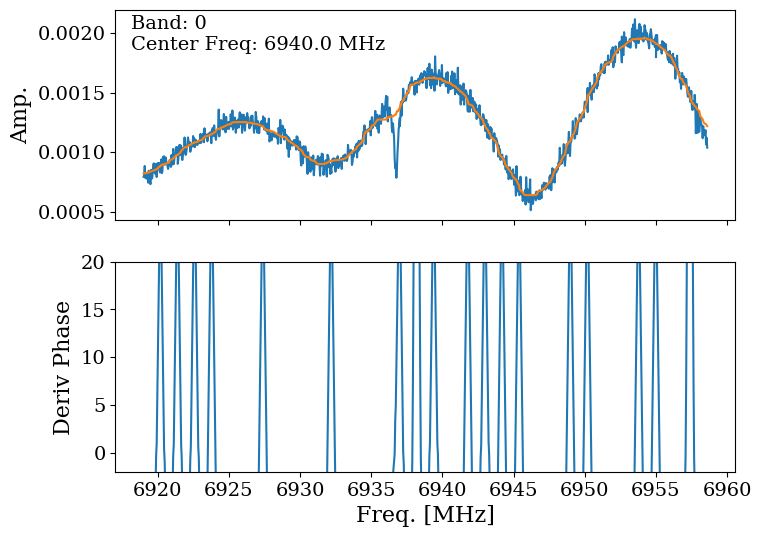

In [125]:
f0, resp0 = freqSweep(S, band=0, start_freq=-20, stop_freq=20, subband=None, tone_power=12, n_avg = 10
                      , makeplot=True)

In [133]:
amp0 = np.abs(resp0)
phase0 = np.angle(resp0)

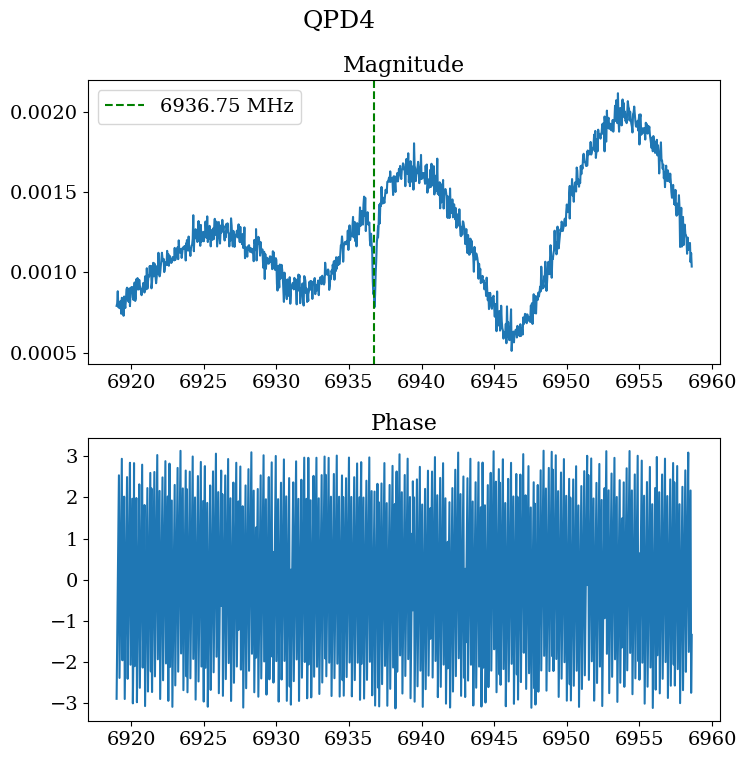

In [131]:
## plot the results
plt.figure(figsize=(7,8))
plt.subplot(2,1,1)
plt.plot(f0, amp0)
#plt.plot(f3, invertedDoubleLorentzian(f3, *popt), 'r-', label = 'fit')
#plt.axvline(x=f0_1, color='r', linestyle='--', label=f'{f0_1} MHz')
#plt.axvline(x=f0_2, color='r', linestyle='--', label=f'{f0_2} MHz')
plt.axvline(x=f_QPD4, color='g', linestyle='--', label=f'{f_QPD4} MHz')
#plt.axis([8360,8380,-.0001,.0003])
plt.title('Magnitude')
plt.legend()
plt.subplot(2,1,2)
plt.plot(f0, phase0)
plt.title('Phase')
plt.suptitle(f'QPD4')
plt.tight_layout(rect=[0, 0.03, 1.1, 0.95])

[ 2026-05-29 00:34:03 ]  Sweeping across frequencies 6420.0MHz to 6460.0MHz. Averaging 10 traces.
[ 2026-05-29 00:34:03 ]  Working on band 1
[ 2026-05-29 00:34:08 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:34:08 ]  Working on band 1
[ 2026-05-29 00:34:15 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:34:15 ]  Working on band 1
[ 2026-05-29 00:34:20 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:34:20 ]  Working on band 1
[ 2026-05-29 00:34:26 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:34:26 ]  Working on band 1
[ 2026-05-29 00:34:32 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:34:32 ]  Working on band 1
[ 2026-05-29 00:34:38 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:34:38 ]  Working on band 1
[ 2026-05-29 00:34:44 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:34:44 ]  Working on band 1
[ 2026-05-29 00:34:49 ]  serial f

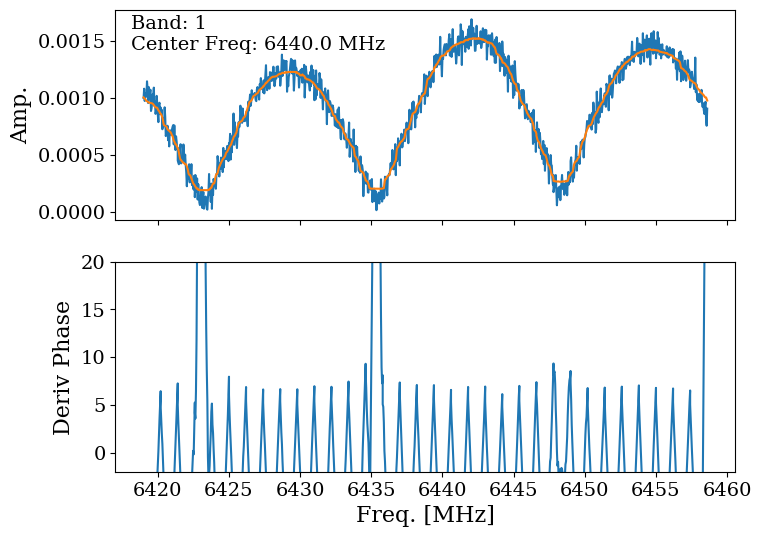

In [110]:
f1, resp1 = freqSweep(S, band=1, start_freq=-20, stop_freq=20, subband=None, tone_power=6, n_avg = 10
                      , makeplot=True)

[ 2026-05-29 00:39:12 ]  Sweeping across frequencies 6420.0MHz to 6460.0MHz. Averaging 20 traces.
[ 2026-05-29 00:39:13 ]  Working on band 1
[ 2026-05-29 00:39:17 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:39:17 ]  Working on band 1
[ 2026-05-29 00:39:22 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:39:22 ]  Working on band 1
[ 2026-05-29 00:39:27 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:39:28 ]  Working on band 1
[ 2026-05-29 00:39:32 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:39:32 ]  Working on band 1
[ 2026-05-29 00:39:37 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:39:37 ]  Working on band 1
[ 2026-05-29 00:39:42 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:39:42 ]  Working on band 1
[ 2026-05-29 00:39:47 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:39:47 ]  Working on band 1
[ 2026-05-29 00:39:52 ]  serial f

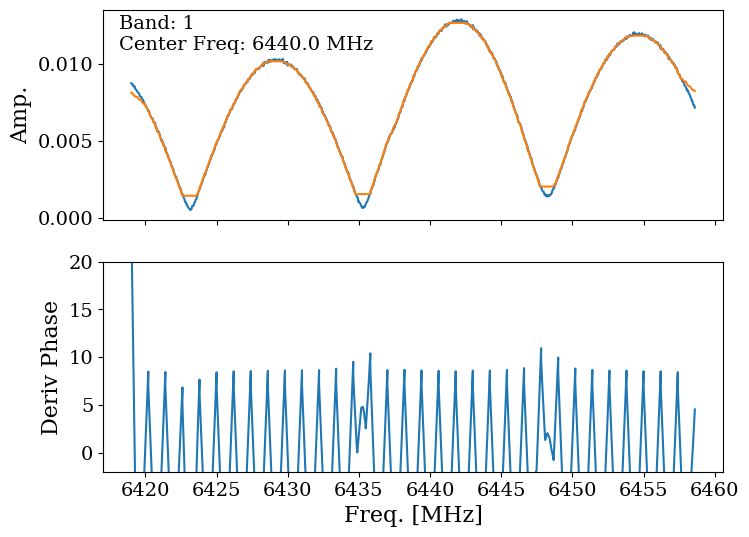

In [112]:
f1, resp1 = freqSweep(S, band=1, start_freq=-20, stop_freq=20, subband=None, tone_power=12, n_avg = 20
                      , makeplot=True)

[ 2026-05-29 00:40:59 ]  Sweeping across frequencies 6430.0MHz to 6450.0MHz. Averaging 20 traces.
[ 2026-05-29 00:40:59 ]  Working on band 1
[ 2026-05-29 00:41:03 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:41:03 ]  Working on band 1
[ 2026-05-29 00:41:07 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:41:07 ]  Working on band 1
[ 2026-05-29 00:41:11 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:41:11 ]  Working on band 1
[ 2026-05-29 00:41:16 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:41:16 ]  Working on band 1
[ 2026-05-29 00:41:21 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:41:22 ]  Working on band 1
[ 2026-05-29 00:41:26 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:41:26 ]  Working on band 1
[ 2026-05-29 00:41:29 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:41:29 ]  Working on band 1
[ 2026-05-29 00:41:33 ]  serial f

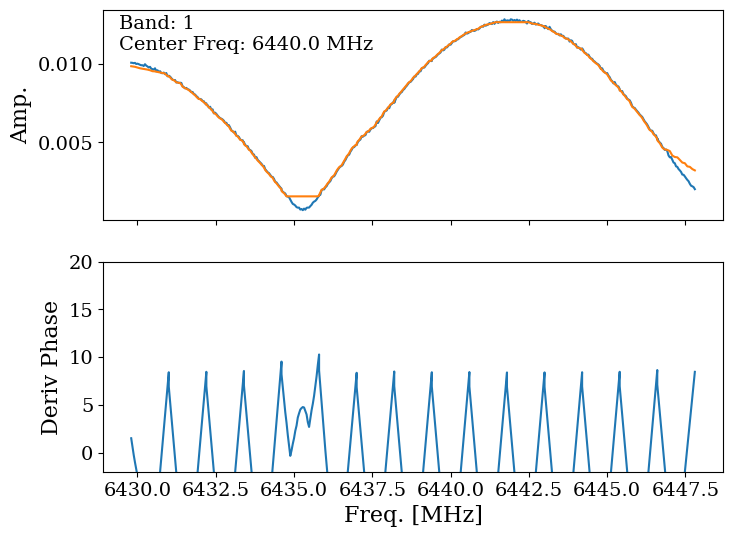

In [113]:
f1, resp1 = freqSweep(S, band=1, start_freq=-10, stop_freq=10, subband=None, tone_power=12, n_avg = 20
                      , makeplot=True)

In [136]:
amp1 = np.abs(resp1)
phase1 = np.angle(resp1)

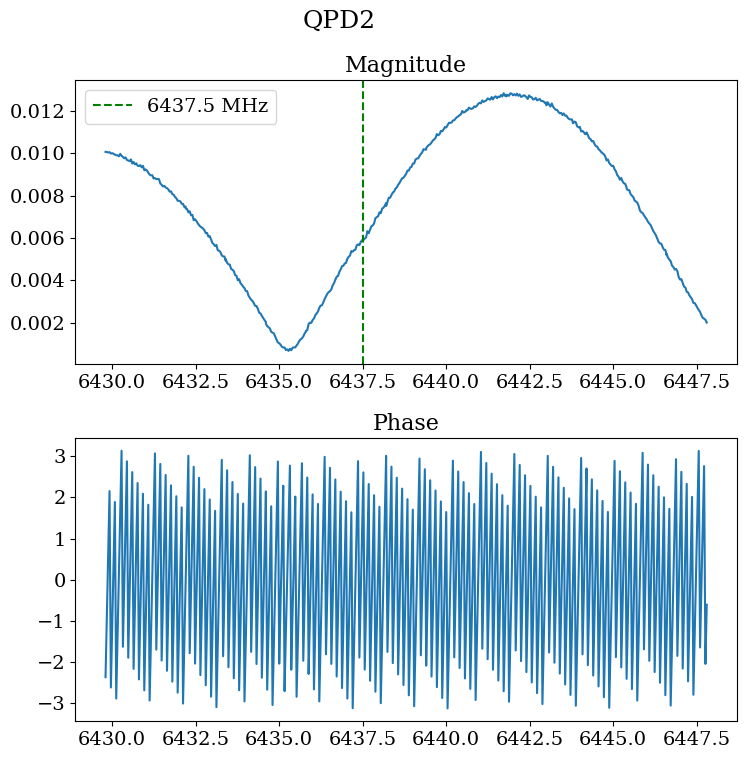

In [139]:
## plot the results
plt.figure(figsize=(7,8))
plt.subplot(2,1,1)
plt.plot(f1, amp1)
#plt.plot(f3, invertedDoubleLorentzian(f3, *popt), 'r-', label = 'fit')
#plt.axvline(x=f0_1, color='r', linestyle='--', label=f'{f0_1} MHz')
#plt.axvline(x=f0_2, color='r', linestyle='--', label=f'{f0_2} MHz')
plt.axvline(x=f_QPD2, color='g', linestyle='--', label=f'{f_QPD2} MHz')
#plt.axis([8360,8380,-.0001,.0003])
plt.title('Magnitude')
plt.legend()
plt.subplot(2,1,2)
plt.plot(f1, phase1)
plt.title('Phase')
plt.suptitle(f'QPD2')
plt.tight_layout(rect=[0, 0.03, 1.1, 0.95])

## Set tones

In [142]:
S.set_band_center_mhz(band0,LO_freq_MHz_band0-750)
f_QPD4_IF = 750 + (S.get_band_center_mhz(band = band0) - f_QPD4)

In [143]:
S.set_band_center_mhz(band1,LO_freq_MHz_band1-750)
f_QPD2_IF = 750 + (S.get_band_center_mhz(band = band1) - f_QPD2)

In [236]:
S.all_off()

S.set_band_center_mhz(band0,750)
S.set_band_center_mhz(band1,750)

my_log = f'Sending fixed tone at {f_QPD4_IF} MHz'
print(my_log)
S.log(my_log)
(band_0, channel4) = S.set_fixed_tone(f_QPD4_IF, 12)

my_log = f'Sending fixed tone at {f_QPD2_IF} MHz'
print(my_log)
S.log(my_log)
(band_1, channel2) = S.set_fixed_tone(f_QPD2_IF, 15)

# my_log = f'Sending fixed tone at {f_leftparityband_IF} MHz'
# print(my_log)
# S.log(my_log)
# (band, channel_left) = S.set_fixed_tone(f_leftparityband_IF, 12)

# my_log = f'Sending fixed tone at {f_rightparityband_IF} MHz'
# print(my_log)
# S.log(my_log)
# (band, channel_right) = S.set_fixed_tone(f_rightparityband_IF, 12)

[ 2026-05-29 03:14:30 ]  Turning off tones
[ 2026-05-29 03:14:46 ]  Turning off flux ramp
[ 2026-05-29 03:14:46 ]  Turning off all TES biases
Sending fixed tone at 753.25 MHz
[ 2026-05-29 03:14:46 ]  Sending fixed tone at 753.25 MHz
Sending fixed tone at 752.5 MHz
[ 2026-05-29 03:14:47 ]  Sending fixed tone at 752.5 MHz


In [237]:
print(f"band_0 = {band_0}")
print(f"band_1 = {band_1}")

band_0 = 0
band_1 = 0


In [238]:
print(f"S.which_on(0) = {S.which_on(0)}")
print(f"S.which_on(1) = {S.which_on(1)}")
print(f"channel4 = {channel4}; channel2 = {channel2}")
# print(f"channel1 = {channel1}, channel2 = {channel2}")

S.which_on(0) = [128 384]
S.which_on(1) = []
channel4 = 384; channel2 = 128


In [239]:
S.which_on(band0)

array([128, 384])

In [240]:
S.which_on(band1)

array([], dtype=int64)

[ 2026-05-29 03:14:50 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:DaqMuxV2[0]:DataBufferSize 524288
[ 2026-05-29 03:14:50 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:DebugSelect[0] 0
[ 2026-05-29 03:14:51 ]  ADC plot saved to /data/smurf_data/20260528/1780004240/plots/1780024490_adc0.png
[ 2026-05-29 03:14:51 ]  Saving raw adc data to /data/smurf_data/20260528/1780004240/outputs/1780024490_adc0


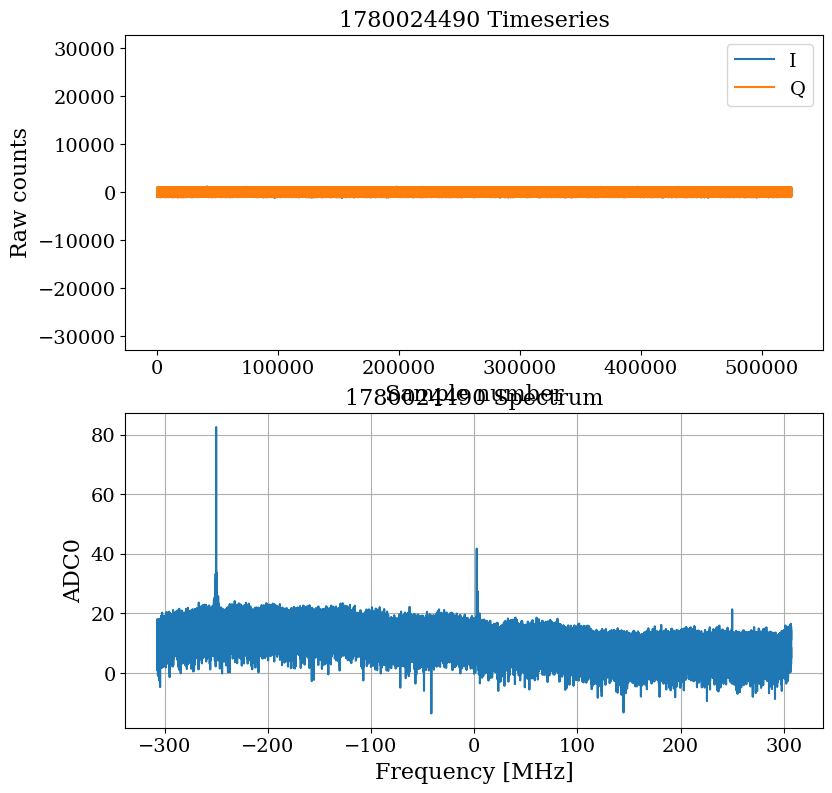

In [241]:
adc=S.read_adc_data(band = band0, make_plot=True,show_plot=True)

[ 2026-05-29 03:14:53 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:DaqMuxV2[0]:DataBufferSize 524288
[ 2026-05-29 03:14:53 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:DebugSelect[0] 1
[ 2026-05-29 03:14:55 ]  ADC plot saved to /data/smurf_data/20260528/1780004240/plots/1780024494_adc1.png
[ 2026-05-29 03:14:55 ]  Saving raw adc data to /data/smurf_data/20260528/1780004240/outputs/1780024494_adc1


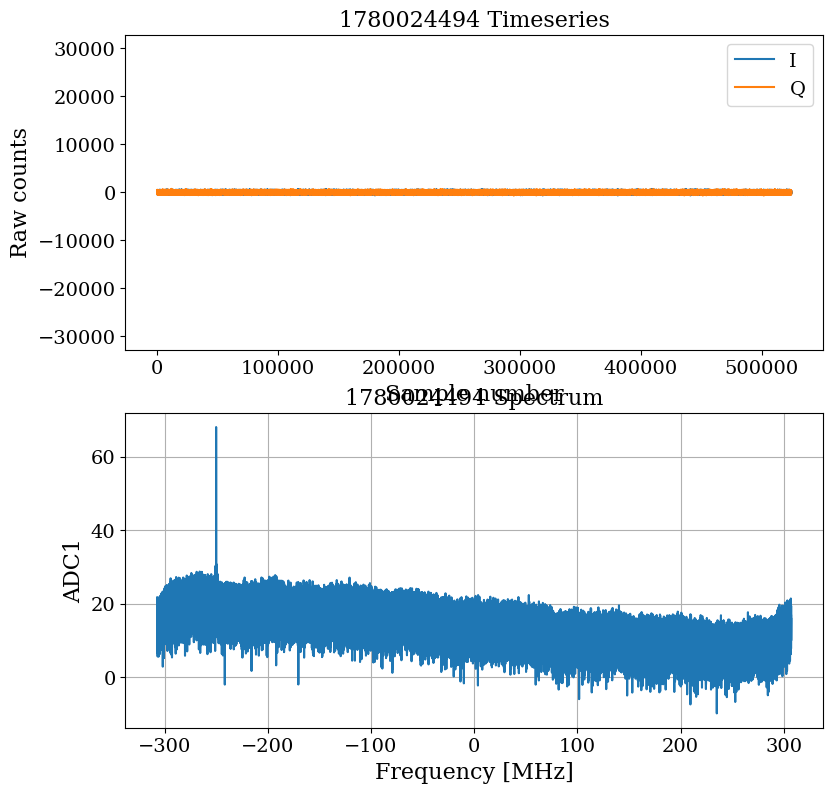

In [242]:
adc=S.read_adc_data(band = band1,make_plot=True,show_plot=True)

## Streaming settings

In [194]:
S.get_sample_frequency() #in Hz

10000.0

In [195]:
S.get_timing_mode()

'ext_ref'

In [196]:
# S.set_timing_mode('ext_ref')

In [197]:
S.get_timing_mode()

'ext_ref'

In [152]:
S.set_lms_gain(band0,7)
S.set_lms_gain(band1,7)

In [153]:
from pysmurf.client.util.SmurfFileReader import SmurfStreamReader
S._caput(f'{S.app_core}baySelStream', 0, write_log=True)
S._caput(f'{S.app_core}modeStream', 1,write_log=True)
print(f"baySelStream: {S._caget(f'{S.app_core}baySelStream',write_log=True)}")
print(f"modeStream: {S._caget(f'{S.app_core}modeStream',write_log=True)}")

[ 2026-05-29 01:00:50 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:baySelStream 0
[ 2026-05-29 01:00:50 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:modeStream 1
[ 2026-05-29 01:00:50 ]  caget smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:baySelStream
[ 2026-05-29 01:00:50 ]  0
baySelStream: 0
[ 2026-05-29 01:00:50 ]  caget smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:modeStream
[ 2026-05-29 01:00:50 ]  1
modeStream: 1


In [154]:
S.stream_data_off()

# Sample rate (can't go above 38ish)
S.flux_ramp_setup(10,0) # first number in kHz, 2nd number only matters for uMUX

[ 2026-05-29 01:01:22 ]  caput smurf_server_s3:AMCc:SmurfProcessor:FileWriter:Close 1
[ 2026-05-29 01:01:22 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:enableStreaming 0
[ 2026-05-29 01:01:22 ]  Waiting 0.15 seconds after...
[ 2026-05-29 01:01:23 ]  Done waiting.
[ 2026-05-29 01:01:23 ]  Percent full scale = 0.000%


In [155]:
# Configure filter / downsample
S.set_filter_disable(False) # I probably want to filter?
S.set_downsample_factor(1)

print(f'S.get_sample_frequency()={S.get_sample_frequency()}')
print(f'S.get_downsample_factor()={S.get_downsample_factor()}')
print(f'S.get_filter_disable()={S.get_filter_disable()}')

S.get_sample_frequency()=10000.0
S.get_downsample_factor()=1
S.get_filter_disable()=0


In [156]:
import scipy.signal as signal
# I think this configures for a 12 kHz roll-off.
b, a = signal.butter(4, 12.0 / 37.5)
S.set_filter_a(a)
S.set_filter_b(b)

## Take stream data

In [210]:
t_stream = 10. #seconds

In [243]:
# loss counter tells you if you lost any frames btw rfsoc and pcie card.  
# Very unlikely at these channel counts, but good to check.
cnt0=S.get_frame_count()
losscnt0=S.get_frame_loss_cnt()

# Here IQ_mode tells the data-taking and read-back that we're taking data in the nonstandard I/Q mode.
data_file=S.take_stream_data(t_stream, IQ_mode=True)

cnt1=S.get_frame_count()
losscnt1=S.get_frame_loss_cnt()

[ 2026-05-29 03:15:29 ]  Starting to take data.
[ 2026-05-29 03:15:29 ]  Input downsample factor is None. Using value already in pyrogue: 1
[ 2026-05-29 03:15:29 ]  CryoCard.do_read failed, retry 1 / 5.
[ 2026-05-29 03:15:29 ]  CryoCard.do_read failed, retry 2 / 5.
[ 2026-05-29 03:15:29 ]  CryoCard.do_read failed, retry 3 / 5.
[ 2026-05-29 03:15:29 ]  CryoCard.do_read failed, retry 4 / 5.
[ 2026-05-29 03:15:29 ]  CryoCard.do_read failed, retry 5 / 5.
[ 2026-05-29 03:15:29 ]  flux_ramp_ac_dc_relay status: Failed to read from cryo card.
[ 2026-05-29 03:15:29 ]  flux_ramp_ac_dc_relay_status = None - NOT A VALID STATE.
[ 2026-05-29 03:15:33 ]  caput smurf_server_s3:AMCc:SmurfProcessor:Unwrapper:reset 1
[ 2026-05-29 03:15:33 ]  caput smurf_server_s3:AMCc:SmurfProcessor:Filter:reset 1
[ 2026-05-29 03:15:33 ]  Writing to file : /data/smurf_data/20260528/1780004240/outputs/1780024534.dat
[ 2026-05-29 03:15:33 ]  /data/smurf_data/20260528/1780004240/outputs/1780024534_mask.txt
[ 2026-05-29 03:1

In [244]:
print(f'Number of frames = {cnt1-cnt0}')
print(f'Number of frames lost = {losscnt1-losscnt0}')

Number of frames = 106637
Number of frames lost = 0


In [245]:
print(f'Expected {t_stream/(1./(1.e3*S.get_flux_ramp_freq()))} frames')

Expected 100000.0 frames


## Read stream data

In [221]:
from smurf_data_loader2 import *

In [246]:
data_file = "/data/smurf_data/20260528/1780004240/outputs/1780024534.dat"
filesize_MB = os.path.getsize(data_file)/1024**2
print(f'file size: {filesize_MB} MB')

file size: 14.520613670349121 MB


In [247]:
d, h, m = read_smurf_data_array(data_file)

first pass read to count frames
starting to scan file
at last byte
15225967 15225967
done scanning file
found {'num_data_frames': 100123, 'num_metadata_frames': 12, 'max_channels': 4, 'max_metadata_size': 710} in file


In [248]:
d.shape

(100123, 4)

In [249]:
d_restructured = d[:, 0::2] + 1j*d[:, 1::2]

In [250]:
d_restructured.shape

(100123, 2)

In [251]:
print(S.get_channel_frequency_mhz(band0))
print(S.get_channel_frequency_mhz(band1))

2.4
2.4


In [252]:
accum_factor0=(1.e6*S.get_channel_frequency_mhz(band0))/(S.get_flux_ramp_freq()*1.e3)
bit_factor0=2**(12-S.get_lms_gain(band0))*2**(7) # this 

print(f'bit_factor0 = {bit_factor0}')
print(f'accum_factor0= {accum_factor0}')

accum_factor1=(1.e6*S.get_channel_frequency_mhz(band1))/(S.get_flux_ramp_freq()*1.e3)
bit_factor1=2**(12-S.get_lms_gain(band1))*2**(7) # this 

print(f'bit_factor1 = {bit_factor1}')
print(f'accum_factor1 = {accum_factor1}')

bit_factor0 = 4096
accum_factor0= 240.0
bit_factor1 = 4096
accum_factor1 = 240.0


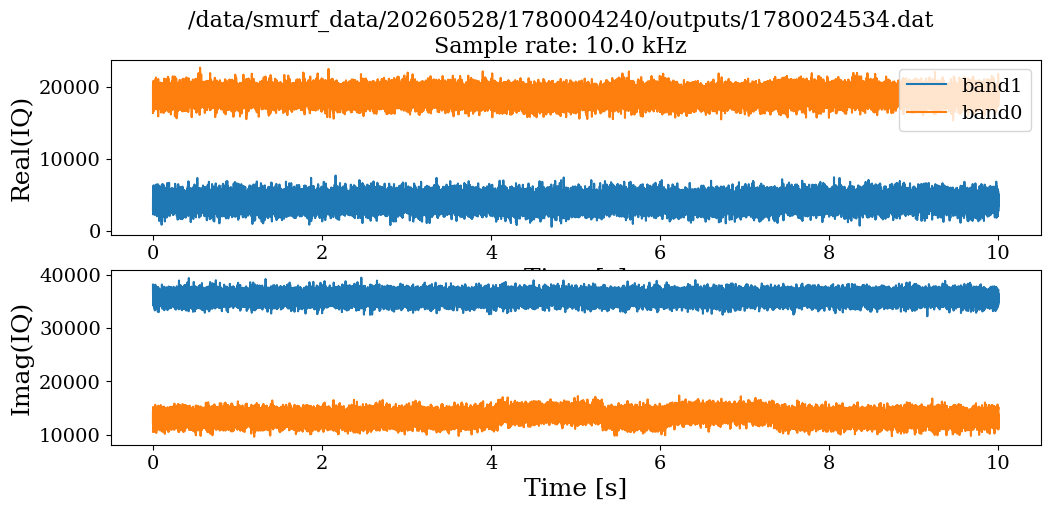

In [253]:
fs = S.get_sample_frequency()

start_plot_time_s = 0
stop_plot_time_s = 10

yoffset=20000
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5))
band = band0 #either band would work

channel_dict = {384: 'band0', 128: 'band1'}

for ch in range(len(S.which_on(band))):
    num_channel = S.which_on(band)[ch]
    
    ych=bit_factor0*d_restructured[:,ch]/accum_factor0
    ymax=np.max(ych)
    ymin=np.min(ych)
    yspan=ymax-ymin
    ymedian=np.median(ych)

    ## Find indices that best match times
    times = np.arange(len(ych)) / fs
    start_plot_idx = np.argmin(np.abs(times - start_plot_time_s))
    stop_plot_idx = np.argmin(np.abs(times - stop_plot_time_s))
    
    ax1.plot(times[start_plot_idx:stop_plot_idx], np.real(ych[start_plot_idx:stop_plot_idx]) + yoffset*ch, label = channel_dict[num_channel])
    ax1.set_ylabel('Real(IQ)',fontsize=18)
    ax1.set_xlabel('Time [s]',fontsize=18)
    ax2.plot(times[start_plot_idx:stop_plot_idx], np.imag(ych[start_plot_idx:stop_plot_idx]) + yoffset*ch, label = None)
    ax2.set_ylabel('Imag(IQ)',fontsize=18)
    ax2.set_xlabel('Time [s]',fontsize=18)
    fig.suptitle(data_file+'\n'+f'Sample rate: {fs/1e3} kHz',fontsize=16)
    ax1.legend(loc = 'upper right')    
plt.show()

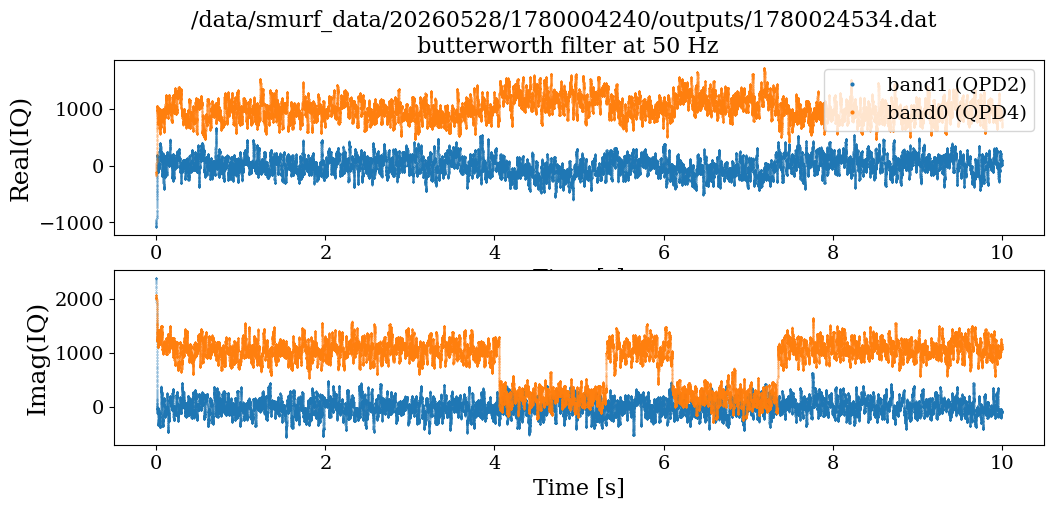

In [254]:
cutoff_hz = 50
order = 2

start_plot_time_s = 0
stop_plot_time_s = 10

band = band0 #either band would work

channel_dict = {384: 'band0 (QPD4)', 128: 'band1 (QPD2)'}

yoffset=1000
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5))
for ch in range(len(S.which_on(band))):
    num_channel = S.which_on(band)[ch]
    
    ych=bit_factor*d_restructured[:, ch]/accum_factor

    ## Find indices that best match times
    times = np.arange(len(ych)) / fs
    start_plot_idx = np.argmin(np.abs(times - start_plot_time_s))
    stop_plot_idx = np.argmin(np.abs(times - stop_plot_time_s))

    butter_ivals = np.abs(butterworth_filter(cutoff_hz=cutoff_hz, order=order, data=np.real(ych), fs=fs))
    ivals_median = np.median(butter_ivals)
    butter_qvals = np.abs(butterworth_filter(cutoff_hz=cutoff_hz, order=order, data=np.imag(ych), fs=fs))
    qvals_median = np.median(butter_qvals)

    ax1.plot(times[start_plot_idx:stop_plot_idx], butter_ivals[start_plot_idx:stop_plot_idx] - ivals_median + yoffset*ch, '.',label=channel_dict[num_channel], markersize=0.4)
    ax1.set_ylabel('Real(IQ)',fontsize=18)
    ax1.set_xlabel('Time [s]')
    ax2.plot(times[start_plot_idx:stop_plot_idx], butter_qvals[start_plot_idx:stop_plot_idx] - qvals_median + yoffset*ch,'.', label=None, markersize=0.4)
    ax2.set_ylabel('Imag(IQ)',fontsize=18)
    ax2.set_xlabel('Time [s]')
    ax1.legend(loc = 'upper right', markerscale = 10)
    fig.suptitle(data_file+f'\n butterworth filter at {cutoff_hz} Hz',fontsize=16)
plt.show()

## Trying to see QPD4 on Band1

In [66]:
LO_freq_MHz_band1 = 6940 + 750
S.set_band_center_mhz(band1,LO_freq_MHz_band1-750)

[ 2026-05-29 00:21:26 ]  Sweeping across frequencies 6920.0MHz to 6960.0MHz. Averaging 10 traces.
[ 2026-05-29 00:21:26 ]  Working on band 1
[ 2026-05-29 00:21:32 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:21:32 ]  Working on band 1
[ 2026-05-29 00:21:37 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:21:37 ]  Working on band 1
[ 2026-05-29 00:21:43 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:21:44 ]  Working on band 1
[ 2026-05-29 00:21:49 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:21:49 ]  Working on band 1
[ 2026-05-29 00:21:55 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:21:55 ]  Working on band 1
[ 2026-05-29 00:22:01 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:22:01 ]  Working on band 1
[ 2026-05-29 00:22:06 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-05-29 00:22:06 ]  Working on band 1
[ 2026-05-29 00:22:11 ]  serial f

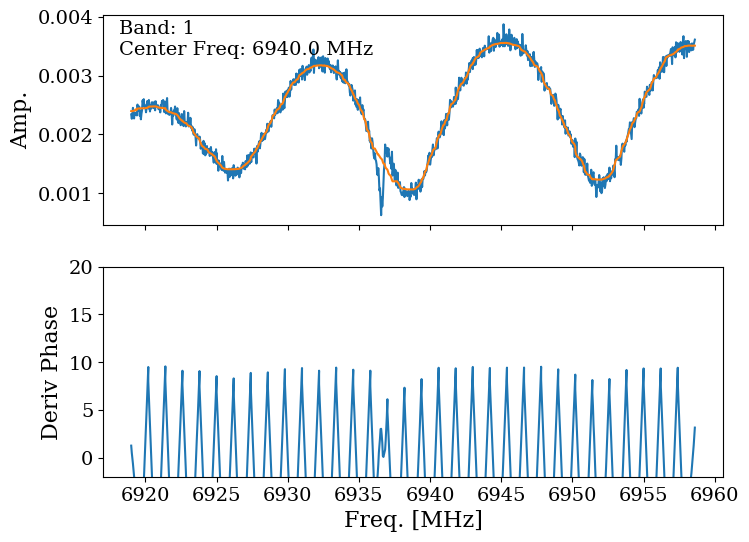

In [96]:
f1, resp1 = freqSweep(S, band=1, start_freq=-20, stop_freq=20, subband=None, tone_power=10, n_avg = 10
                      , makeplot=True)

[ 2026-05-29 00:20:03 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:DaqMuxV2[0]:DataBufferSize 524288
[ 2026-05-29 00:20:03 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:DebugSelect[0] 1
[ 2026-05-29 00:20:05 ]  ADC plot saved to /data/smurf_data/20260528/1780004240/plots/1780014004_adc1.png
[ 2026-05-29 00:20:05 ]  Saving raw adc data to /data/smurf_data/20260528/1780004240/outputs/1780014004_adc1


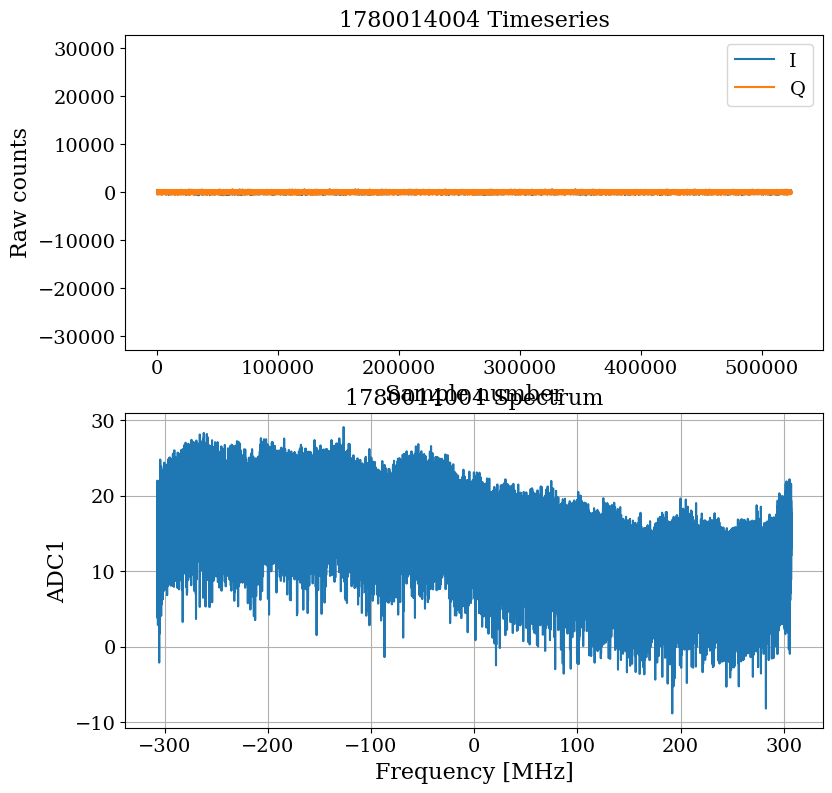

In [94]:
adc=S.read_adc_data(band = band1,make_plot=True,show_plot=True)

## Trying to see QPD4 on Band2

In [61]:
S.all_off()

[ 2026-05-28 22:54:12 ]  Turning off tones
[ 2026-05-28 22:54:26 ]  Turning off flux ramp
[ 2026-05-28 22:54:26 ]  Turning off all TES biases


In [50]:
LO_freq_MHz_band1 = 6940 + 750
S.set_band_center_mhz(band2,LO_freq_MHz_band1-750)

In [52]:
S.get_band_center_mhz(band2)

6940.0

[ 2026-05-28 22:55:10 ]  Sweeping across frequencies 6690.0MHz to 7190.0MHz. Averaging 1 traces.
[ 2026-05-28 22:55:10 ]  Working on band 2
[ 2026-05-28 22:55:43 ]  serial find freq complete ; etaScanInProgress = 0


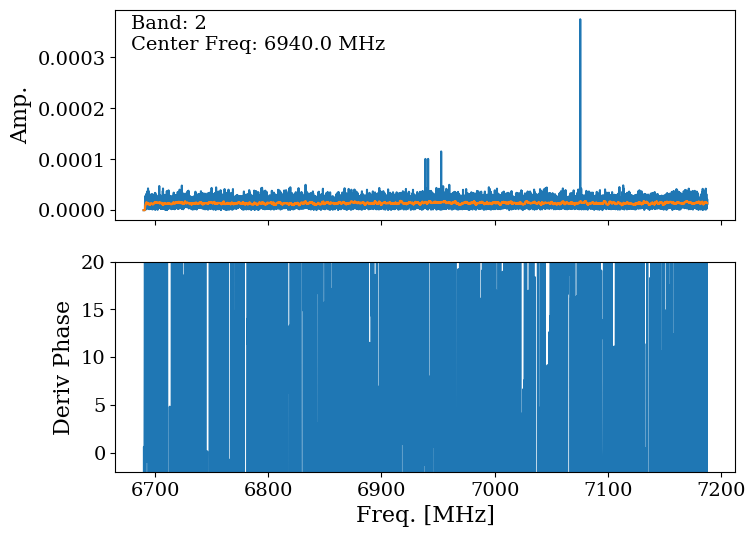

In [64]:
f2, resp2 = freqSweep(S, band=band2, start_freq=-250, stop_freq=250, subband=None, tone_power=12, n_avg = 1
                      , makeplot=True)

[ 2026-05-28 22:55:51 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:DaqMuxV2[0]:DataBufferSize 524288
[ 2026-05-28 22:55:51 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:DebugSelect[0] 2
[ 2026-05-28 22:55:53 ]  ADC plot saved to /data/smurf_data/20260528/1780004240/plots/1780008952_adc2.png
[ 2026-05-28 22:55:53 ]  Saving raw adc data to /data/smurf_data/20260528/1780004240/outputs/1780008952_adc2


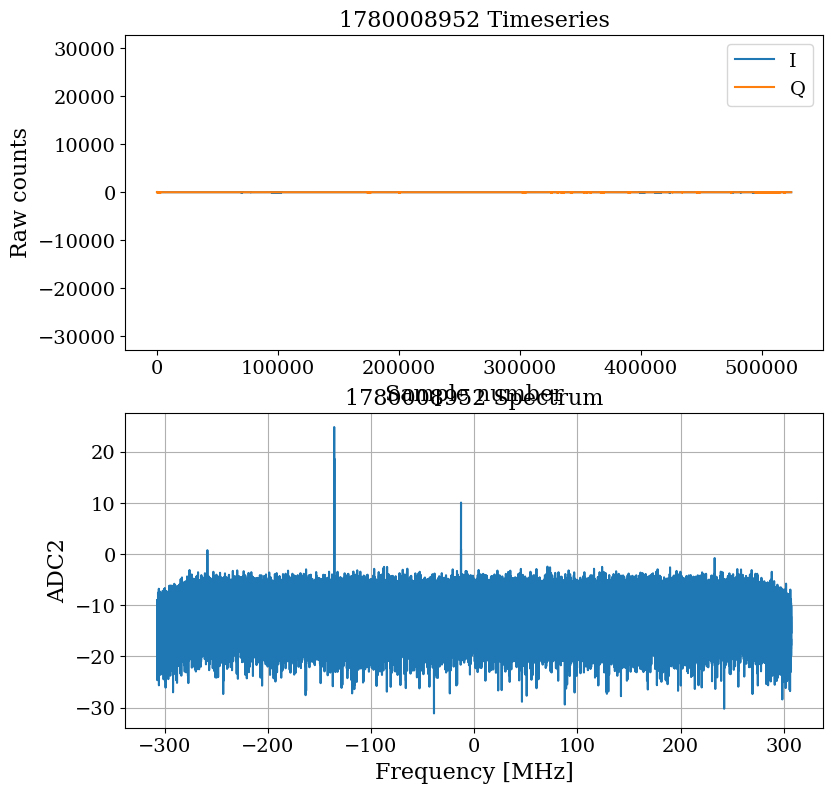

In [65]:
adc=S.read_adc_data(band = band2,make_plot=True,show_plot=True)

## Checking noise between bands
Hardware: each band connected in loopback. Fake frequencies

[ 2026-05-28 23:21:27 ]  Sweeping across frequencies 6740.0MHz to 7140.0MHz. Averaging 1 traces.
[ 2026-05-28 23:21:27 ]  Working on band 0
[ 2026-05-28 23:21:54 ]  serial find freq complete ; etaScanInProgress = 0


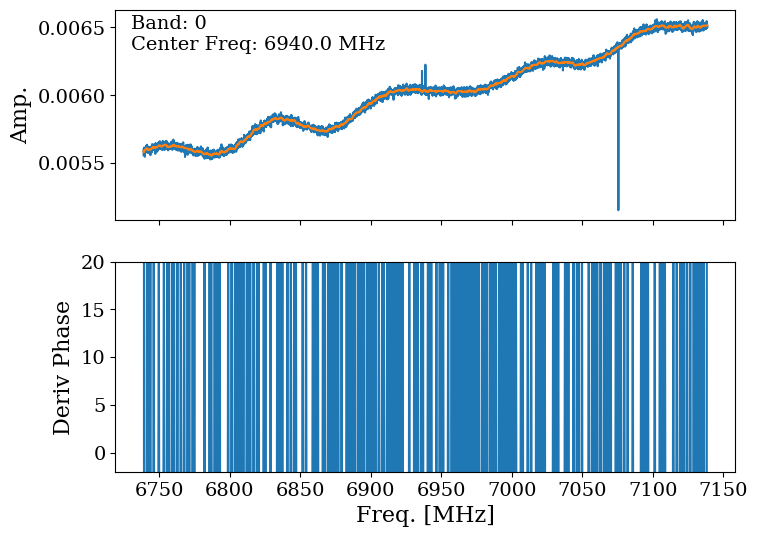

In [75]:
f0, resp0 = freqSweep(S, band=band0, start_freq=-200, stop_freq=200, subband=None, tone_power=12, n_avg = 1
                      , makeplot=True)

[ 2026-05-28 23:25:51 ]  Sweeping across frequencies 6740.0MHz to 7140.0MHz. Averaging 1 traces.
[ 2026-05-28 23:25:51 ]  Working on band 1
[ 2026-05-28 23:26:17 ]  serial find freq complete ; etaScanInProgress = 0


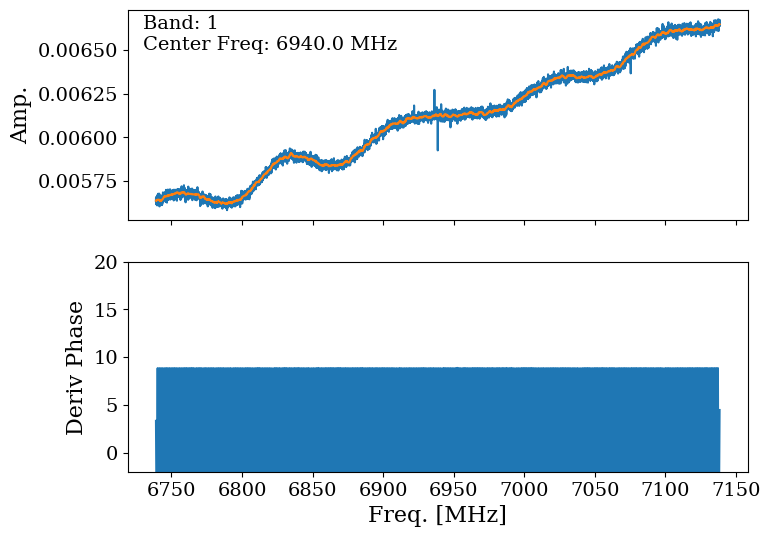

In [76]:
f1, resp1 = freqSweep(S, band=band1, start_freq=-200, stop_freq=200, subband=None, tone_power=12, n_avg = 1
                      , makeplot=True)

### Now with each band wired up to the fridge
Real frequencies

[ 2026-05-28 23:39:44 ]  Sweeping across frequencies 6740.0MHz to 7140.0MHz. Averaging 1 traces.
[ 2026-05-28 23:39:45 ]  Working on band 0
[ 2026-05-28 23:40:12 ]  serial find freq complete ; etaScanInProgress = 0


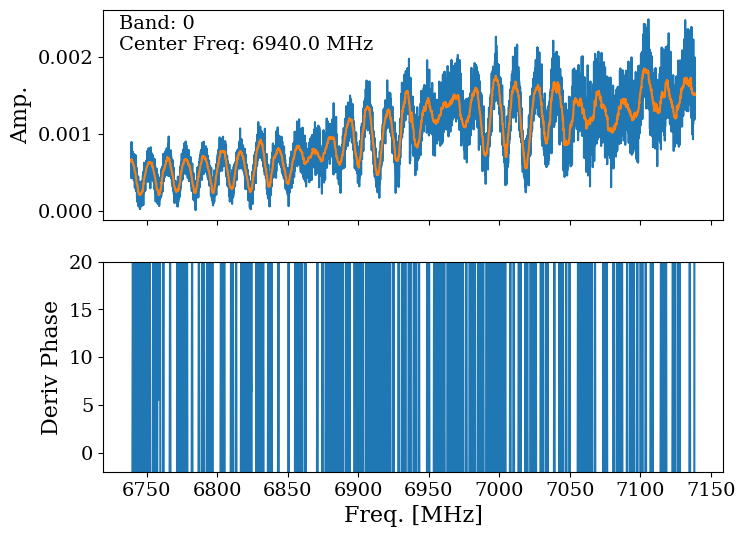

In [77]:
f0, resp0 = freqSweep(S, band=band0, start_freq=-200, stop_freq=200, subband=None, tone_power=12, n_avg = 1
                      , makeplot=True)

[ 2026-05-28 23:40:15 ]  Sweeping across frequencies 6740.0MHz to 7140.0MHz. Averaging 1 traces.
[ 2026-05-28 23:40:15 ]  Working on band 1
[ 2026-05-28 23:40:43 ]  serial find freq complete ; etaScanInProgress = 0


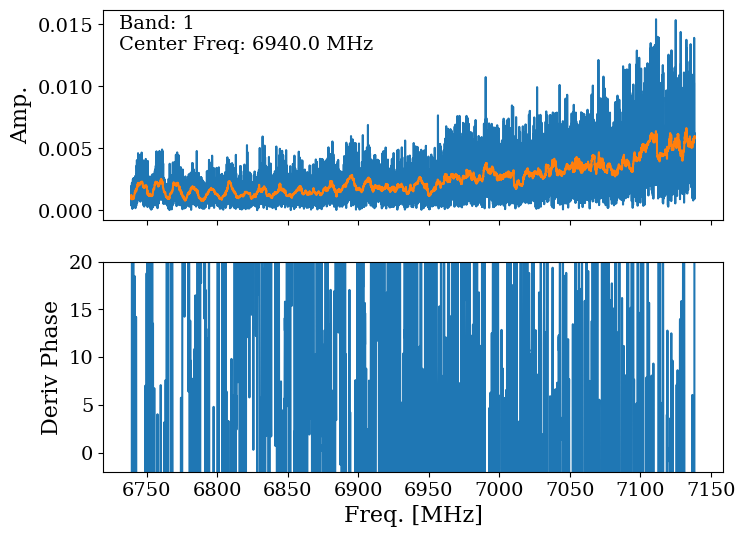

In [78]:
f1, resp1 = freqSweep(S, band=band1, start_freq=-200, stop_freq=200, subband=None, tone_power=12, n_avg = 1
                      , makeplot=True)

Looks like the level of band1 is 5X larger than band0. Noise is similar between the two but noise is much higher on band1, especially towards the end of the band (that's probably the roll off of the 5000-7000 MHz BPF). Trying band1 with the band0 LO, maybe the LO is adding a lot of noise?

[ 2026-05-28 23:43:36 ]  Sweeping across frequencies 6740.0MHz to 7140.0MHz. Averaging 1 traces.
[ 2026-05-28 23:43:36 ]  Working on band 1
[ 2026-05-28 23:44:03 ]  serial find freq complete ; etaScanInProgress = 0


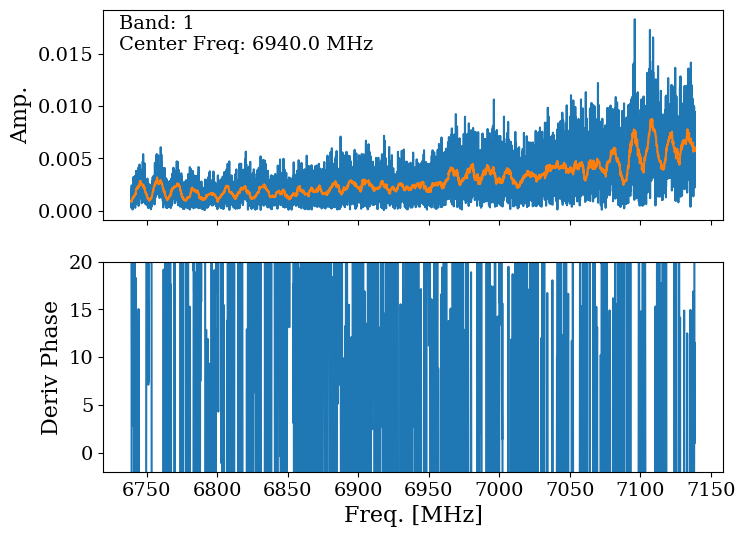

In [79]:
f1, resp1 = freqSweep(S, band=band1, start_freq=-200, stop_freq=200, subband=None, tone_power=12, n_avg = 1
                      , makeplot=True)

Switched out the filters on the RF chain for band1 to make it more similar to band0. I wonder if noise will change much.

[ 2026-05-28 23:59:28 ]  Sweeping across frequencies 6740.0MHz to 7140.0MHz. Averaging 1 traces.
[ 2026-05-28 23:59:29 ]  Working on band 1
[ 2026-05-28 23:59:56 ]  serial find freq complete ; etaScanInProgress = 0


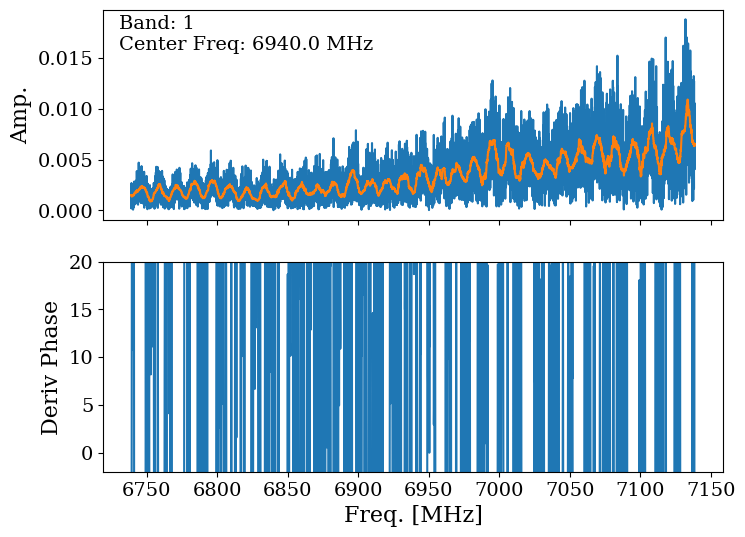

In [81]:
f1, resp1 = freqSweep(S, band=band1, start_freq=-200, stop_freq=200, subband=None, tone_power=12, n_avg = 1
                      , makeplot=True)

Changing amplifier voltage to match levels (went from 5 V to 4 V)

[ 2026-05-29 00:03:02 ]  Sweeping across frequencies 6740.0MHz to 7140.0MHz. Averaging 1 traces.
[ 2026-05-29 00:03:02 ]  Working on band 1
[ 2026-05-29 00:03:29 ]  serial find freq complete ; etaScanInProgress = 0


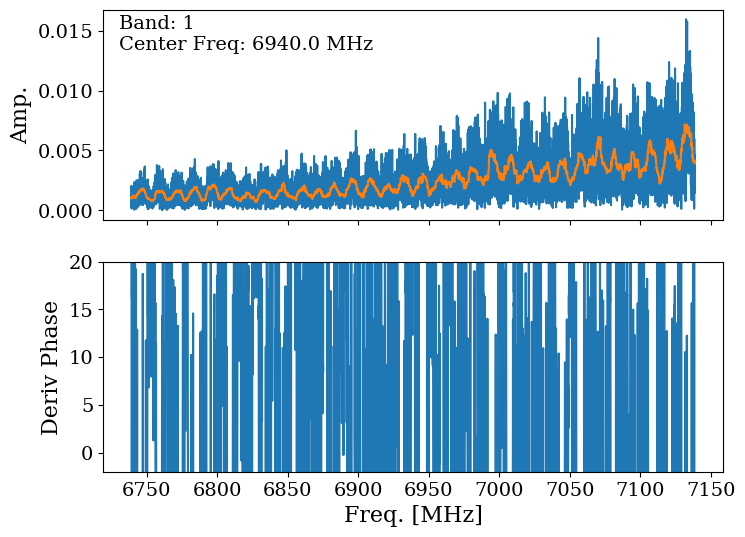

In [82]:
f1, resp1 = freqSweep(S, band=band1, start_freq=-200, stop_freq=200, subband=None, tone_power=12, n_avg = 1
                      , makeplot=True)

[ 2026-05-29 00:04:25 ]  Sweeping across frequencies 6740.0MHz to 7140.0MHz. Averaging 1 traces.
[ 2026-05-29 00:04:25 ]  Working on band 1
[ 2026-05-29 00:04:52 ]  serial find freq complete ; etaScanInProgress = 0


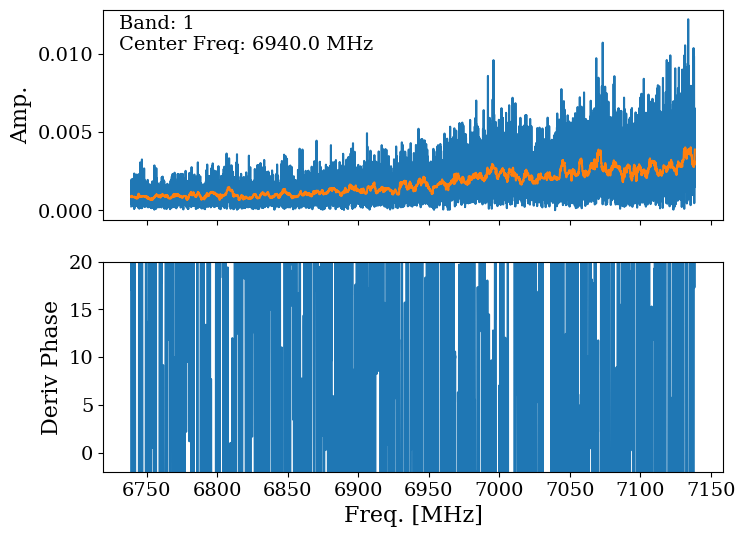

In [83]:
f1, resp1 = freqSweep(S, band=band1, start_freq=-200, stop_freq=200, subband=None, tone_power=10, n_avg = 1
                      , makeplot=True)

[ 2026-05-29 00:06:48 ]  Sweeping across frequencies 6740.0MHz to 7140.0MHz. Averaging 1 traces.
[ 2026-05-29 00:06:48 ]  Working on band 1
[ 2026-05-29 00:07:16 ]  serial find freq complete ; etaScanInProgress = 0


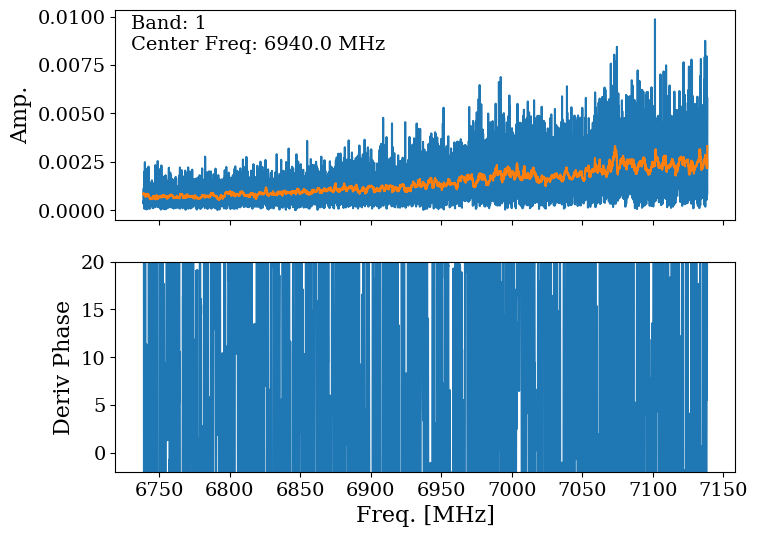

In [86]:
f1, resp1 = freqSweep(S, band=band1, start_freq=-200, stop_freq=200, subband=None, tone_power=6, n_avg = 1
                      , makeplot=True)

[ 2026-05-29 00:07:18 ]  Sweeping across frequencies 6740.0MHz to 7140.0MHz. Averaging 1 traces.
[ 2026-05-29 00:07:18 ]  Working on band 1
[ 2026-05-29 00:07:45 ]  serial find freq complete ; etaScanInProgress = 0


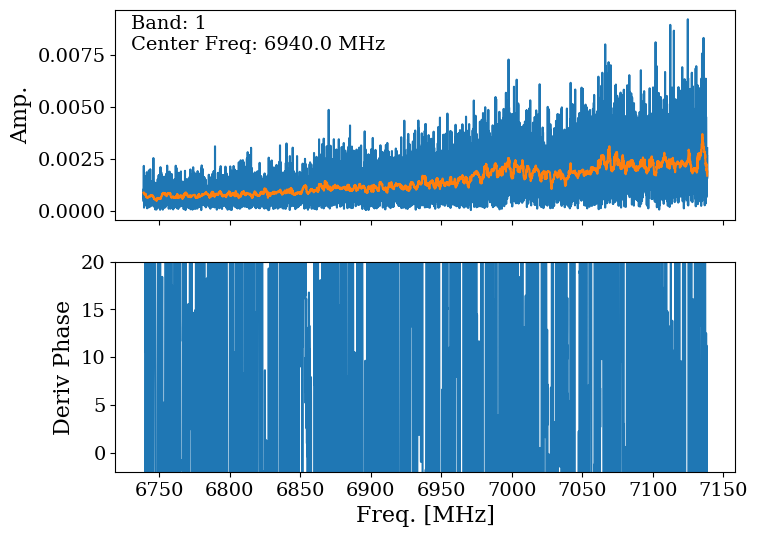

In [87]:
f1, resp1 = freqSweep(S, band=band1, start_freq=-200, stop_freq=200, subband=None, tone_power=3, n_avg = 1
                      , makeplot=True)

[ 2026-05-29 00:10:55 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:DaqMuxV2[0]:DataBufferSize 524288
[ 2026-05-29 00:10:55 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:DebugSelect[0] 0
[ 2026-05-29 00:10:56 ]  ADC plot saved to /data/smurf_data/20260528/1780004240/plots/1780013455_adc0.png
[ 2026-05-29 00:10:56 ]  Saving raw adc data to /data/smurf_data/20260528/1780004240/outputs/1780013455_adc0


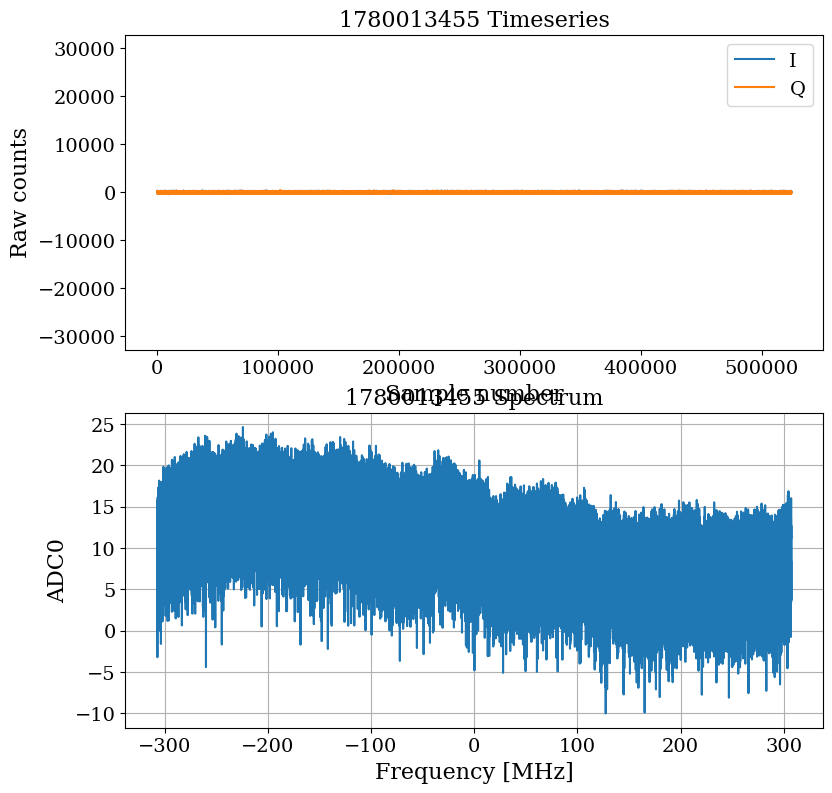

In [88]:
adc=S.read_adc_data(band = band0,make_plot=True,show_plot=True)

[ 2026-05-29 00:10:59 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:DaqMuxV2[0]:DataBufferSize 524288
[ 2026-05-29 00:10:59 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:DebugSelect[0] 1
[ 2026-05-29 00:11:01 ]  ADC plot saved to /data/smurf_data/20260528/1780004240/plots/1780013459_adc1.png
[ 2026-05-29 00:11:01 ]  Saving raw adc data to /data/smurf_data/20260528/1780004240/outputs/1780013459_adc1


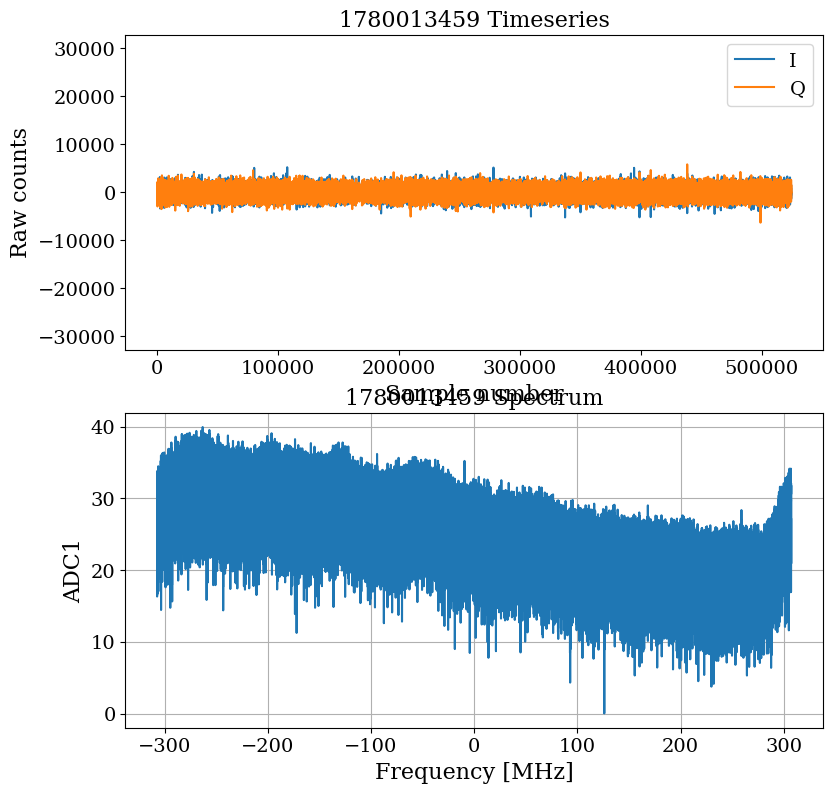

In [89]:
adc=S.read_adc_data(band = band1,make_plot=True,show_plot=True)

Added amp back to output side of smurf, removed amp on input side.

[ 2026-05-29 00:15:36 ]  Sweeping across frequencies 6740.0MHz to 7140.0MHz. Averaging 1 traces.
[ 2026-05-29 00:15:36 ]  Working on band 1
[ 2026-05-29 00:16:04 ]  serial find freq complete ; etaScanInProgress = 0


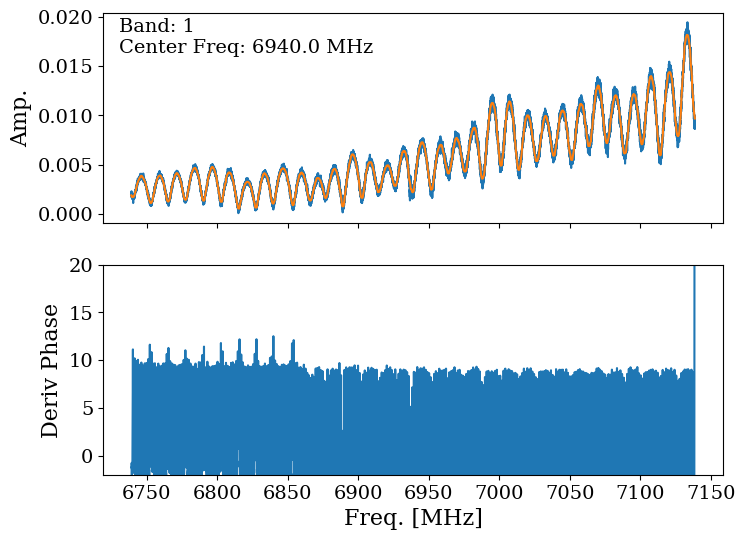

In [90]:
f1, resp1 = freqSweep(S, band=band1, start_freq=-200, stop_freq=200, subband=None, tone_power=12, n_avg = 1
                      , makeplot=True)

[ 2026-05-29 00:20:38 ]  Sweeping across frequencies 6740.0MHz to 7140.0MHz. Averaging 1 traces.
[ 2026-05-29 00:20:38 ]  Working on band 1
[ 2026-05-29 00:21:04 ]  serial find freq complete ; etaScanInProgress = 0


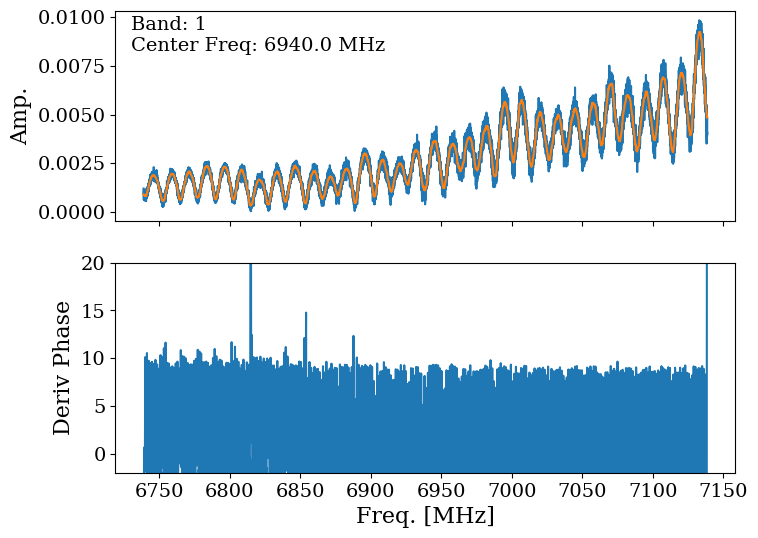

In [95]:
f1, resp1 = freqSweep(S, band=band1, start_freq=-200, stop_freq=200, subband=None, tone_power=10, n_avg = 1
                      , makeplot=True)

Oh nice. Looks just like band0. Lets go back to cells at top. Below are freq sweeps with the appropriate band center for band1

[ 2026-05-29 00:28:36 ]  Sweeping across frequencies 6240.0MHz to 6640.0MHz. Averaging 1 traces.
[ 2026-05-29 00:28:36 ]  Working on band 1
[ 2026-05-29 00:29:04 ]  serial find freq complete ; etaScanInProgress = 0


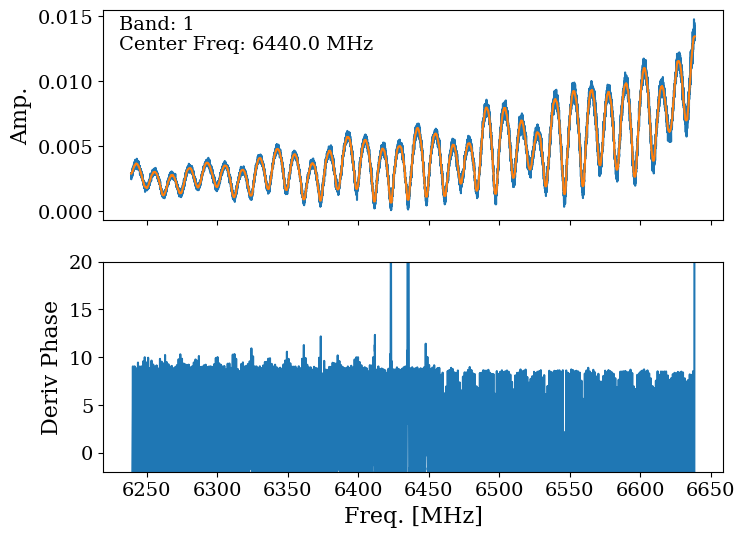

In [107]:
f1, resp1 = freqSweep(S, band=band1, start_freq=-200, stop_freq=200, subband=None, tone_power=10, n_avg = 1
                      , makeplot=True)

[ 2026-05-29 00:31:19 ]  Sweeping across frequencies 6240.0MHz to 6640.0MHz. Averaging 1 traces.
[ 2026-05-29 00:31:19 ]  Working on band 1
[ 2026-05-29 00:31:47 ]  serial find freq complete ; etaScanInProgress = 0


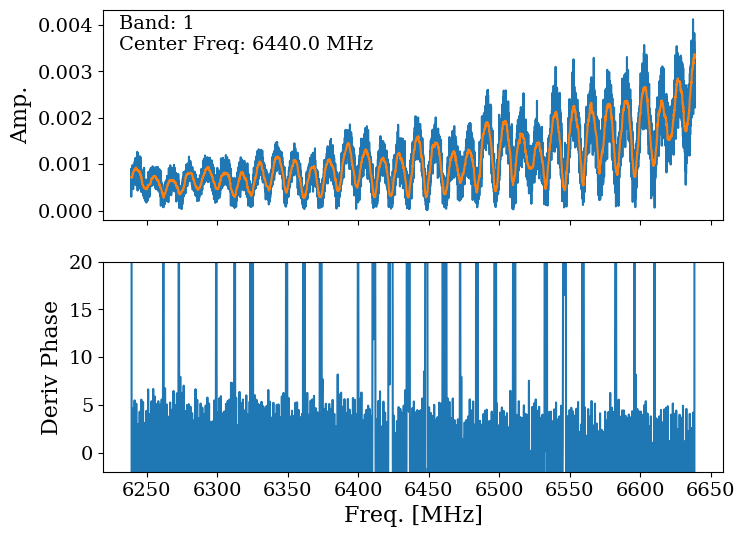

In [109]:
f1, resp1 = freqSweep(S, band=band1, start_freq=-200, stop_freq=200, subband=None, tone_power=6, n_avg = 1
                      , makeplot=True)